# 순환 신경망 기반 감성 분석 (네이버 영화 리뷰)
1. 데이터 준비
2. 모델 구축 및 컴파일
3. 모델 학습
4. 모델 평가
5. 예측
6. 배포 (저장, 재사용)

## 1. 데이터 준비
    1-1. 데이터 로딩
    1-2. 데이터 전처리
    1-3. 데이터 분리 
    1-4. 학습용 데이터 준비
    1-5. 테스트용 데이터준비 

### 1-1. 데이터 로딩

In [1]:
# naver_movie_review.csv
datafile = './data/naver_movie_review.csv'
import pandas as pd
review_df = pd.read_csv(datafile)
review_df.head()

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


### 1-2. 데이터 전처리
- 결측치 제거
- 정제 (한글만 남기고 모두 삭제)
- 중복치 제거
- 형태소 분석기로 토큰화

#### 1-2-1. 결측치 제거

In [2]:
review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        200000 non-null  int64 
 1   document  199992 non-null  object
 2   label     200000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 4.6+ MB


In [3]:
# 결측치 확인 (결측치 개수 확인)
review_df.isnull().sum()

id          0
document    8
label       0
dtype: int64

In [4]:
#결측치가 있는 레코드(행) 확인 
review_df[review_df.document.isnull()]

,id,document,label
25857,2172111,NaN,1
55737,6369843,NaN,1
110014,1034280,NaN,0
126782,5942978,NaN,0
140721,1034283,NaN,0
155746,402110,NaN,1
157899,5026896,NaN,0
177097,511097,NaN,1


In [5]:
# 결측치 제거
review_df.dropna(inplace=True)

In [6]:
review_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199992 entries, 0 to 199999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        199992 non-null  int64 
 1   document  199992 non-null  object
 2   label     199992 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 6.1+ MB


#### 1-2-2. 정제
* 한글과 공백을 제외한 문자는 공백으로 치환하여 제거
* 한글이 없었던 문장은 공백만 남아있게 되므로, 결측치 삭제 처리 진행 필요

In [7]:
import re
import numpy as np  # 결측치 처리를 위해 numpy 임포트

# 1. 한글(자음, 모음, 완성형)과 공백을 제외하고 모두 공백으로 치환
# (기존에 정의한 'cleaned_document' 이름을 그대로 사용합니다)
review_df['cleaned_document'] = review_df.document.apply(lambda x: re.sub('[^ ㄱ-ㅣ가-힣 ]+', ' ', str(x)))

# 2. 문장의 시작 부분에 있는 공백을 제거하고 새로운 컬럼 'clean_doc'에 저장
review_df['clean_doc'] = review_df['cleaned_document'].apply(lambda x: re.sub('^ +', '', x))

# 3. 빈 문자열("")이나 공백만 있는 문자열을 결측치(NaN)로 수정
# (apply 대신 replace 메소드를 사용하면 훨씬 간단하고 안전해요!)
review_df['clean_doc'] = review_df['clean_doc'].replace(r'^\s*$', np.nan, regex=True)

review_df.head()




#import re
#import numpy as np
# 한글과 공백 제외하고 모두 공백으로 치환
#re.sub('[^ 가-힣 ]+', ' ', text)

#review_df['cleaned_document'] = review_df.document.apply(lambda x: re.sub('[^ ㄱ-ㅣ가-힣 ]+', ' ', x))

# 문장의 시작 부분에 있는 공백을 ""으로 치환 
#review_df.clean_doc = review_df.clean_document.apply(lambda x: re.sub('^ +', '', x))


# 빈 문자열("")은 결측치로 수정
#review_df.clean_doc = review_df.clean_doc.apply('',None)

#review_df.head()

,id,document,label,cleaned_document,clean_doc
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0,아 더빙 진짜 짜증나네요 목소리,아 더빙 진짜 짜증나네요 목소리
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1,흠 포스터보고 초딩영화줄 오버연기조차 가볍지 않구나,흠 포스터보고 초딩영화줄 오버연기조차 가볍지 않구나
2,10265843,너무재밓었다그래서보는것을추천한다,0,너무재밓었다그래서보는것을추천한다,너무재밓었다그래서보는것을추천한다
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0,교도소 이야기구먼 솔직히 재미는 없다 평점 조정,교도소 이야기구먼 솔직히 재미는 없다 평점 조정
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1,사이몬페그의 익살스런 연기가 돋보였던 영화 스파이더맨에서 늙어보이기만 했던 커스틴 ...,사이몬페그의 익살스런 연기가 돋보였던 영화 스파이더맨에서 늙어보이기만 했던 커스틴 ...


In [8]:
# 결측치 확인
review_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199992 entries, 0 to 199999
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   id                199992 non-null  int64 
 1   document          199992 non-null  object
 2   label             199992 non-null  int64 
 3   cleaned_document  199992 non-null  object
 4   clean_doc         198315 non-null  object
dtypes: int64(2), object(3)
memory usage: 9.2+ MB


In [9]:
review_df[review_df.clean_doc.isnull()]

,id,document,label,cleaned_document,clean_doc
404,4221289,What is this movie for?,0,,NaN
412,9509970,Yesterday when i was young,1,,NaN
470,10147571,once upon a dream,1,,NaN
584,7117896,1,0,,NaN
593,6478189,4,0,,NaN
...,...,...,...,...,...
199459,6381245,take me for what i am,1,,NaN
199563,2192893,good!,0,,NaN
199803,5309713,good~!,1,,NaN
199871,9767991,dkajlskgjqlkrjgklqejgkle,0,,NaN


In [10]:
# 결측치 제거
review_df.dropna(inplace=True)

In [11]:
review_df.clean_doc.isnull().sum()

0

#### 1-2-3. 중복치 제거

In [12]:
# 중복치 확인
review_df.cleaned_document.duplicated().sum()

6204

In [13]:
review_df[review_df.cleaned_document.duplicated()]

,id,document,label,cleaned_document,clean_doc
1097,2062443,쵝오,1,쵝오,쵝오
1248,3502685,최고,1,최고,최고
1483,775332,최고,1,최고,최고
1707,8009134,재밌다,1,재밌다,재밌다
1804,1043429,볼만함,1,볼만함,볼만함
...,...,...,...,...,...
199841,8097768,2년이 지나도 잊혀지지 않는 소중한 드라마.,1,년이 지나도 잊혀지지 않는 소중한 드라마,년이 지나도 잊혀지지 않는 소중한 드라마
199861,9301787,단순 액션물과 마찬가지로 남는 것 없는 팝콘 무비. 역시 짐 캐리 최고의 영화는 트...,0,단순 액션물과 마찬가지로 남는 것 없는 팝콘 무비 역시 짐 캐리 최고의 영화는 트...,단순 액션물과 마찬가지로 남는 것 없는 팝콘 무비 역시 짐 캐리 최고의 영화는 트...
199923,4540652,재미있게 봤습니다!,1,재미있게 봤습니다,재미있게 봤습니다
199934,6929887,굿,1,굿,굿


In [14]:
# 중복치 제거
review_df.drop_duplicates(subset=['cleaned_document'], inplace=True)

In [15]:
review_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 192111 entries, 0 to 199999
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   id                192111 non-null  int64 
 1   document          192111 non-null  object
 2   label             192111 non-null  int64 
 3   cleaned_document  192111 non-null  object
 4   clean_doc         192111 non-null  object
dtypes: int64(2), object(3)
memory usage: 8.8+ MB


#### 1-2-4. 토큰화

In [16]:
# 형태소 분석기 적용 (Okt, Komoran 등)
from konlpy.tag import Okt
t = Okt()

from tqdm import tqdm
tqdm.pandas()
review_df['tokens'] = review_df['clean_doc'].progress_apply(t.morphs)

100%|██████████| 192111/192111 [03:55<00:00, 814.69it/s]


In [17]:
#review_list = []
#for review in tqdm(list(review_df['clean_doc'[:100]]])):
    #review_list.append([token for token in t.morphs(review)])
    
#review_df['tokens'] = review_list

In [18]:
review_df.head()

,id,document,label,cleaned_document,clean_doc,tokens
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0,아 더빙 진짜 짜증나네요 목소리,아 더빙 진짜 짜증나네요 목소리,"[아, 더빙, 진짜, 짜증나네요, 목소리]"
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1,흠 포스터보고 초딩영화줄 오버연기조차 가볍지 않구나,흠 포스터보고 초딩영화줄 오버연기조차 가볍지 않구나,"[흠, 포스터, 보고, 초딩, 영화, 줄, 오버, 연기, 조차, 가볍지, 않구나]"
2,10265843,너무재밓었다그래서보는것을추천한다,0,너무재밓었다그래서보는것을추천한다,너무재밓었다그래서보는것을추천한다,"[너, 무재, 밓었, 다그, 래서, 보는것을, 추천, 한, 다]"
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0,교도소 이야기구먼 솔직히 재미는 없다 평점 조정,교도소 이야기구먼 솔직히 재미는 없다 평점 조정,"[교도소, 이야기, 구먼, 솔직히, 재미, 는, 없다, 평점, 조정]"
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1,사이몬페그의 익살스런 연기가 돋보였던 영화 스파이더맨에서 늙어보이기만 했던 커스틴 ...,사이몬페그의 익살스런 연기가 돋보였던 영화 스파이더맨에서 늙어보이기만 했던 커스틴 ...,"[사이, 몬페, 그, 의, 익살스런, 연기, 가, 돋보였던, 영화, 스파이더맨, 에..."


### 1-3. 데이터 분리
* 정답 데이터의 분포 확인 -> 학습용 데이터와 테스트 데이터로 분리 시 비율 유지 (stratify=y)

In [19]:
# label 컬럼의 값별 데이터 수 확인
# review_df.label.value_counts()
# review_df.groupby('label').size()
review_df.label.value_counts()

label
0    96343
1    95768
Name: count, dtype: int64

<Axes: xlabel='label'>

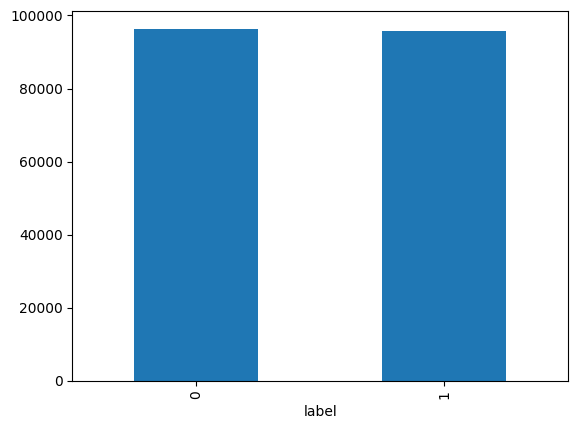

In [20]:
# 막대그래프로 그려보기
# review_df.groupby('label').size().plot(kind='bar') # groupby로 집계한 결과에 plot을 적용 
review_df.label.value_counts().plot(kind='bar')

In [21]:
# 입력 데이터와 정답데이터 추출  (list)
review_list = list(review_df.tokens)
label_list = list(review_df.label)
len(review_list), len(label_list)

(192111, 192111)

In [22]:
# 학습 데이터와 테스트 데이터 분리
from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(review_list, label_list, test_size=0.1)
len(train_X), len(test_X), len(train_y), len(test_y)

(172899, 19212, 172899, 19212)

### 1-4. 학습 데이터 준비
    1-4-1. Integer Encoding을 위한 tokenizer 생성
    1-4-2. 입력 데이터 Integer Encoding
    1-4-3. 입력 데이터 Padding
    1-4-4. 정답 데이터 원핫인코딩

#### 1-4-1. Integer Encoding을 위한 tokenizer 생성
* num_words = 사용할 단어 수(vocab_size) + 1 (0은 OOV에 할당)

In [23]:
# 단어 수 제한없이 Tokenizer 생성하여 단어 수 확인
from tensorflow.keras.preprocessing.text import Tokenizer
test_tokenizer = Tokenizer()
test_tokenizer.fit_on_texts(train_X)
len(test_tokenizer.word_index)

108252

In [24]:
# 등장 빈도수를 threshold로 설정하여 버릴 단어가 차지하는 비율 확인
from mylib.my_utils import rare_word_status
threshold = 3
rare_word_status(threshold, test_tokenizer.word_counts.items())

전체 단어 : (108,252)개: 2,289,849번
희귀 단어 : (등장빈도 3)번 이하: 72,360개 86,519번
전체 단어에서 희귀 단어의 비율: 단어 수 66.84%, 빈도수 3.78%
전체 단어에서 희귀 단어를 제외한 단어의 수: 35,892개, 96.22%,


In [25]:
# 단어 수를 제한하여 tokenizer 생성
num_vocab = 40000
num_words = num_vocab - 1  # 0번 패딩 토큰을 제외한 단어 수
tokenizer = Tokenizer(num_words=num_words)
tokenizer.fit_on_texts(train_X)
len(tokenizer.word_counts), tokenizer.num_words

(108252, 39999)

#### 1-4-2. 입력 데이터 Integer Encoding
* 제한된 단어에만 index를 부여하므로, 희귀 단어로만 구성된 review는 단어가 0이 되므로 결측치에 해당 -> 결측치 제거

In [26]:
# 입력 데이터 Integer Encoding
encoded_train_X = tokenizer.texts_to_sequences(train_X) 
print(len(encoded_train_X), len(train_X))
encoded_train_X[:5]

172899 172899


[[1, 135, 5, 111, 63, 4853],
 [591, 3, 133, 3, 7, 31, 11353],
 [449, 1294, 1285, 6, 5424, 134, 1466],
 [465, 861, 3458, 7856, 164, 2, 9, 645, 1904, 19104, 891, 631, 6, 405],
 [711,
  6544,
  4432,
  2,
  57,
  1968,
  16,
  104,
  8,
  883,
  1336,
  381,
  15820,
  1,
  26,
  7,
  2,
  132]]

In [27]:
# 길이가 0인 리뷰의 index 추출
null_index = [index for index, review in enumerate(encoded_train_X) if len(review) == 0]
len(null_index), null_index[:10]

(358, [804, 1076, 1728, 2287, 3510, 5217, 5316, 5555, 5724, 6136])

In [28]:
# 길이가 0인 리뷰가 있는 경우, 길이가 1 이상인 리뷰로 학습데이터 재구성
new_train_X = [review for index, review in enumerate(encoded_train_X) if index not in null_index]
new_train_y = [label for index, label in enumerate(train_y) if index not in null_index]
len(new_train_X), len(new_train_y)

(172541, 172541)

In [29]:
new_train_X = []
new_train_y = []
for i in range(len(encoded_train_X)):
    if len(encoded_train_X[i]) == 0:
        new_train_X.append(encoded_train_X[i])  # 길이가 0인 리뷰는 그대로 추가
        new_train_y.append(train_y[i])  # 해당 리뷰의 레이블도 추가
        
len(new_train_X), len(new_train_y)

(358, 358)

#### 1-4-3. 입력 데이터 padding
* 입력 데이터의 길이(max_len)를 정하여 padding

array([[<Axes: title={'center': '0'}>]], dtype=object)

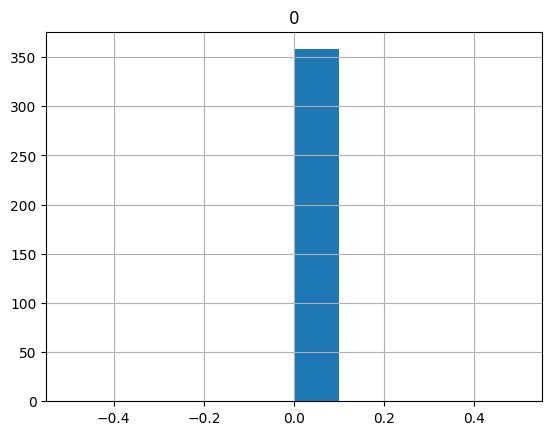

In [30]:
# 리뷰 길이 분포 확인 (히스토그램 그려보기)
len_df = pd.DataFrame([len(review) for review in new_train_X])
len_df.hist()

In [31]:
# 최대, 최소, 평균 등 정보 확인
len_df.describe()

,0
count,358.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


In [32]:
import importlib
import mylib.my_utils
importlib.reload(mylib.my_utils)

<module 'mylib.my_utils' from 'd:\\Lecture\\TextMining_26\\mylib\\my_utils.py'>

In [33]:
from mylib.my_utils import below_threshold_len
# 길이가 max_len 이하인 데이터의 비중 확인
max_len = 55
below_threshold_len(max_len, new_train_X)

길이가 55 이하인 텍스트의 비율: 100.0000%


In [34]:
# max_len 길이로 입력 데이터 padding
from tensorflow.keras.preprocessing.sequence import pad_sequences
train_X = pad_sequences(new_train_X, maxlen=max_len)
len(train_X), train_X[:2]

(358,
 array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]))

#### 1-4-4. 정답 데이터 one-hot encoding

In [35]:
from tensorflow.keras.utils import to_categorical
train_y = to_categorical(new_train_y)
len(train_y), train_y[:2]

(358,
 array([[1., 0.],
        [1., 0.]], dtype=float32))

### 1-5. 테스트 데이터 준비
    1-5-1. 입력 데이터 Integer Encoding (결측치제거) 
    1-5-2. 입력 데이터 padding
    1-5-3. 정답 데이터 one-hot encoding

In [36]:
# 입력 데이터 Integer Encoding
encoded_test_X = tokenizer.texts_to_sequences(test_X)
print(len(encoded_test_X), encoded_test_X[:2])

19212 [[15822, 894, 1276, 274, 4356], [15, 1, 2, 25, 1, 1, 83, 180, 285, 49, 7, 856, 472, 37, 13, 56, 3, 75, 8, 7, 1, 26, 67, 1534, 75, 12606, 5796, 301, 2849, 16, 409, 2]]


In [37]:
# 길이가 0인 리뷰의 index 추출 -> 있으면 길이가 1 이상인 리뷰만으로 테스트 데이터 재구성 
null_index = [index for index, review in enumerate(encoded_test_X) if len(review) < 0]
len(null_index)

0

In [38]:
new_test_X = [review for index, review in enumerate(encoded_test_X) if index not in null_index]
new_test_y = [review for index, review in enumerate(test_y) if index not in null_index]
len(new_test_X), len(new_test_y)

(19212, 19212)

In [39]:
# 입력 데이터 padding
test_X = pad_sequences(new_test_X, maxlen=max_len)
len(test_X), test_X[:2]

(19212,
 array([[    0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0, 15822,   894,  1276,   274,
          4356],
        [    0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,    15,     1,     2,    25,
             1,     1,    83,   180,   285,    49,     7,   856,   472,
            37,    13,    56,     3,    75,     8,     7,     1,    26,
            67,  1534,    75, 12606,  5796,   301,  2849,    16,   409,
             2]]))

In [40]:
# 정답 데이터 one-hot encoding
test_y = to_categorical(new_test_y)
len(test_y), test_y[:2]

(19212,
 array([[1., 0.],
        [1., 0.]], dtype=float32))

## 2. 모델 구축 및 컴파일

In [41]:
# 모델 설계
from tensorflow.keras.layers import Embedding, LSTM, Dense
# Embedding layer의 파라미터    입력 차원과 출력 차원, 입력 길이 설정
num_features = num_words
embedding_dim = 32
input_length = max_len

rnn_nodes = 32 # RNN layer의 노드 수 설정
output_nodes = 2 # 출력 노드 수 설정 (긍정/부정 2개 클래스)
dense_nodes = 16 # Dense layer의 노드 수 설정 (RNN layer와 출력 layer 사이에 위치하는 은닉층의 노드 수)

rnn_model = [
    Embedding(num_features, embedding_dim, input_length=input_length),
    LSTM(rnn_nodes),
    Dense(dense_nodes, activation='tanh'),
    Dense(output_nodes, activation='softmax')
]

In [42]:
# 모델 생성
from tensorflow.keras.models import Sequential
model = Sequential(rnn_model)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 55, 32)            1279968   
                                                                 
 lstm (LSTM)                 (None, 32)                8320      
                                                                 
 dense (Dense)               (None, 16)                528       
                                                                 
 dense_1 (Dense)             (None, 2)                 34        
                                                                 
Total params: 1,288,850
Trainable params: 1,288,850
Non-trainable params: 0
_________________________________________________________________


In [43]:
# 학습 설계 : 생성한 모델에 학습 관련 하이퍼파라미터를 설정 
from tensorflow.keras.optimizers import RMSprop 
model.compile(loss='binary_crossentropy', metrics='accuracy', optimizer=RMSprop(learning_rate=0.001))
# 손실함수는 'binary_crossentropy'로 설정, 평가 지표는 'accuracy'로 설정, 최적화 알고리즘은 RMSprop으로 설정하고 학습률을 0.001로 지정

In [44]:
# EarlyStopping, ModelCheckpoint callback 함수 설정
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint 
# 콜백 함수는 모델 학습 과정에서 특정 조건이 만족될 때 자동으로 호출되는 함수입니다.

es = EarlyStopping(monitor='val_loss', mode='min', patience=3, verbose=1) # 검증 데이터의 손실이 3회 연속으로 개선되지 않으면 학습을 중단 
# 모니터링할 지표는 'val_loss'로 설정, 개선이 없으면 학습을 중단하는 기준은 'min'으로 설정, verbose=1로 설정하여 학습 중단 시 메시지 출력, 
# patience=3으로 설정하여 개선이 없을 때 3회 연속으로 기다린 후 학습을 중단하도록 설정
checkpoint_filepath = './model/best_model.h5'  # 모델을 저장할 파일 경로 설정

mc = ModelCheckpoint(checkpoint_filepath, monitor='val_loss', mode='min', save_best_only=True, verbose=1) 
# 모델 체크포인트 콜백 설정, monitor='val_loss'로 검증 손실을 모니터링, mode='min'으로 손실이 최소가 되는 모델 저장, 
# save_best_only=True로 가장 좋은 모델만 저장, verbose=1로 메시지 출력

## 3. 모델 학습

In [45]:
# 모델 학습
model.fit(train_X, train_y, epochs=20, batch_size=128, validation_split=0.1, callbacks=[es, mc])

Epoch 1/20
1/3 [=========>....................] - ETA: 2s - loss: 0.6933 - accuracy: 0.5078
Epoch 1: val_loss improved from inf to 0.68943, saving model to ./model\best_model.h5
3/3 [==============================] - 2s 270ms/step - loss: 0.6930 - accuracy: 0.5093 - val_loss: 0.6894 - val_accuracy: 0.5556
Epoch 2/20
1/3 [=========>....................] - ETA: 0s - loss: 0.6860 - accuracy: 0.5938
Epoch 2: val_loss did not improve from 0.68943
3/3 [==============================] - 0s 25ms/step - loss: 0.6946 - accuracy: 0.5155 - val_loss: 0.6905 - val_accuracy: 0.5556
Epoch 3/20
1/3 [=========>....................] - ETA: 0s - loss: 0.6948 - accuracy: 0.4766
Epoch 3: val_loss did not improve from 0.68943
3/3 [==============================] - 0s 30ms/step - loss: 0.6930 - accuracy: 0.5155 - val_loss: 0.6904 - val_accuracy: 0.5556
Epoch 4/20
1/3 [=========>....................] - ETA: 0s - loss: 0.6922 - accuracy: 0.5234
Epoch 4: val_loss did not improve from 0.68943
3/3 [===============

## 4. 모델 평가

In [46]:
# 저장된 모델 로딩하여, 테스트 데이터로 평가
model.load_weights(checkpoint_filepath)  # 저장된 모델의 가중치를 로드하여 모델에 적용
test_loss, test_acc = model.evaluate(test_X, test_y)
print(f'정확도 : {test_acc*100:.3f}%')

601/601 [==============================] - 2s 3ms/step - loss: 0.6930 - accuracy: 0.5083
정확도 : 50.828%


In [47]:
# predict로 테스트 데이터의 예측값 구기기
import numpy as np
result = model.predict(test_X)
print(result[:5])
labels = ['부정', '긍정']
user_outputs = [labels[np.argmax(result)] for result in result]
print(user_outputs[:10])

601/601 [==============================] - 2s 3ms/step
[[0.47744542 0.52255464]
 [0.48969468 0.5103054 ]
 [0.4808869  0.51911306]
 [0.47424316 0.5257569 ]
 [0.48219356 0.5178065 ]]
['긍정', '긍정', '긍정', '긍정', '긍정', '긍정', '긍정', '긍정', '긍정', '긍정']


In [49]:
# sklearn의 classification_report()로 평가 결과 확인
from sklearn.metrics import classification_report
# 예측값을 클래스 레이블로 변환 (0 또는 1)
pred_labels = [0, 1]
preds = [pred_labels[np.argmax(result)] for result in result]
print(classification_report(new_test_y, preds))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      9447
           1       0.51      1.00      0.67      9765

    accuracy                           0.51     19212
   macro avg       0.25      0.50      0.34     19212
weighted avg       0.26      0.51      0.34     19212



c:\Users\user\anaconda3\envs\textmine26\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\anaconda3\envs\textmine26\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\anaconda3\envs\textmine26\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

## 5. 예측

In [50]:
# 입력된 리뷰에 대한 긍부정 판단 함수
def analyze_sentiment(review):
    # 데이터 준비 : 정제, # 한국어 형태소 분석기 적용, Integer Encoding, padding
    tokens = [word for word in t.morphs(review)]
    encoded_tokens = tokenizer.texts_to_sequences([tokens])
    X = pad_sequences(encoded_tokens, maxlen=max_len)
    # 모델 예측
    results = model.predict(X, verbose=0)
    # 예측 결과 해석
    labels = ['부정', '긍정']
    index = np.argmax(results[0])
    user_outputs = labels[index]
    # 예측된 레이블 반환
    return user_outputs, results[0][index]

In [51]:
# 함수 테스트
reviews = [
    '이 영화 개꿀잼 ㅋㅋㅋ',
    '하품만 나온다',
    '이 영화 핵노잼 ㅠㅠ',
    '이딴게 영화냐 ㅉㅉ',
    '와 개쩐다',
    '감독 뭐하는 놈이냐',
    '정말 세계관 최강자들의 영화다'
]

for review in reviews:
    user_output, prob = analyze_sentiment(review)
    print(f'{review} --> {user_output} ({prob*100:.2f}%)')

이 영화 개꿀잼 ㅋㅋㅋ --> 긍정 (52.61%)
하품만 나온다 --> 긍정 (52.25%)
이 영화 핵노잼 ㅠㅠ --> 긍정 (52.52%)
이딴게 영화냐 ㅉㅉ --> 긍정 (51.68%)
와 개쩐다 --> 긍정 (52.91%)
감독 뭐하는 놈이냐 --> 긍정 (51.65%)
정말 세계관 최강자들의 영화다 --> 긍정 (51.59%)


## 6. 배포 (모델 저장 및 재사용)
    6-1. 모델 저장
    6-2. SentimentAnalyzer 클래스 구현
        *  저장된 모델 로딩 및 사용

### 6-1. 모델 저장 

In [52]:
# t (Okt 객체) -> Okt 클래스 활용하여 생성
# keras 학습 모델저장 
model.save('./model/sa_movie_model.keras')

In [53]:
# Integer Encoding을 위한 파이썬 객체 직렬화 (encoder) : tokenizer 객체 저장
# 직렬화 라이브러리 임포트
import joblib
joblib.dump(tokenizer, './model/sa_movie_encoder.pkl')


['./model/sa_movie_encoder.pkl']

### 6-2. SentimentAnalyzer 클래스 구현
- 객체 생성 시 예측 모델, Integer Encoder 로딩
- 한국어 형태소 분석기 정의
- 입력된 리뷰의 긍부정 판단 함수

In [54]:
from tensorflow.keras.models import load_model
from konlpy.tag import Okt
class Sentiment_Analyzer:
    def __init__(self, model_file, encoder_file):
        self.model = load_model(model_file)
        self.encoder = joblib.load(encoder_file)
        self.korean_tokenizer = Okt().morphs
    
    def analyze_sentiment(review):
        # 데이터 준비 : 정제, # 한국어 형태소 분석기 적용, Integer Encoding, padding
        tokens = [word for word in self.korean_tokenizer(review)]
        encoded_tokens = self.encoder.texts_to_sequences([tokens])
        X = pad_sequences(encoded_tokens)#, maxlen=self.model.input_shape[1])
        # 모델 예측
        results = self.model.predict(X, verbose=0)
        # 예측 결과 해석
        labels = ['부정', '긍정']
        index = np.argmax(results[0])
        user_outputs = labels[index]
        # 예측된 레이블 반환
        return user_outputs, results[0][index]

In [55]:
sa = Sentiment_Analyzer('./model/sa_movie_model.keras', './model/sa_movie_encoder.pkl')

reviews = [
    '이 영화 개꿀잼 ㅋㅋㅋ',
    '하품만 나온다',
    '이 영화 핵노잼 ㅠㅠ',
    '이딴게 영화냐 ㅉㅉ',
    '와 개쩐다',
    '감독 뭐하는 놈이냐',
    '정말 세계관 최강자들의 영화다'
]

for review in reviews:
    user_output, prob = analyze_sentiment(review)
    print(f'{review} --> {user_output} ({prob*100:.2f}%)')

이 영화 개꿀잼 ㅋㅋㅋ --> 긍정 (52.61%)
하품만 나온다 --> 긍정 (52.25%)
이 영화 핵노잼 ㅠㅠ --> 긍정 (52.52%)
이딴게 영화냐 ㅉㅉ --> 긍정 (51.68%)
와 개쩐다 --> 긍정 (52.91%)
감독 뭐하는 놈이냐 --> 긍정 (51.65%)
정말 세계관 최강자들의 영화다 --> 긍정 (51.59%)
